In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub
import tensorly as tl
import plotly.io as pio
pio.renderers.default = 'iframe'
tl.set_backend('cupy')
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')
print(f'TensorLy tenalg backend: {tl.tenalg.get_backend()}')

env: CUPY_ACCELERATORS=cutensor,cub
TensorLy backend: cupy
TensorLy tenalg backend: einsum


In [2]:
from moabb.paradigms import FilterBankMotorImagery, MotorImagery
from moabb.datasets import *
from hoda.tensorize import fh_power, fh_log_envelope
from hoda.classification import ZLogRatio, ZScore
dataset = AlexMI()
dataset.event_id




{'right_hand': 2, 'feet': 3, 'rest': 4}

In [3]:
events = list(dataset.event_id.keys())[:3]
events

['right_hand', 'feet', 'rest']

In [4]:
sfreq=250
paradigm = MotorImagery(events=events, n_classes=3, resample=sfreq)
paradigm.used_events(dataset)

{'right_hand': 2, 'feet': 3, 'rest': 4}

In [5]:
X, y, meta = paradigm.get_data(
     dataset=dataset, 
     #subjects=[1],
     return_epochs=False
)


/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>

/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>

/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>

/data/leuven/352/vsc35289/miniconda3/envs/bttda-cuda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline of

In [8]:
import numpy as np
np.unique(y)

array(['feet', 'rest', 'right_hand'], dtype='<U10')

In [9]:
X.shape

(480, 16, 750)

In [10]:
import sys
sys.path.append('../')
from classification_mi import stf_transform 
from hoda.classification import ZScore
X_tfr_base = stf_transform(X)
X_tfr_base = ZScore().fit_transform(X_tfr_base)
X_tfr_base = tl.tensor(X_tfr_base)

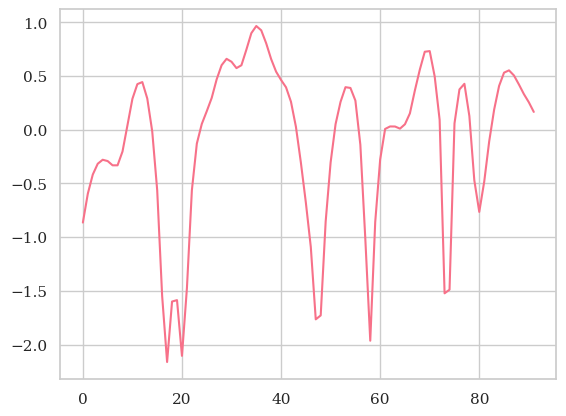

In [11]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
plt.plot(tl.to_numpy(X_tfr_base[0,1,4,:]))
plt.show()

In [12]:
X_tfr_base.shape

(480, 16, 17, 92)

In [13]:
import plotly.express as px
import numpy as np

px.imshow(np.cov(tl.to_numpy(tl.unfold(X_tfr_base,1))))

In [14]:
px.imshow(np.cov(tl.to_numpy(tl.unfold(X_tfr_base,2))))

In [15]:
px.imshow(np.cov(tl.to_numpy(tl.unfold(X_tfr_base,3))))

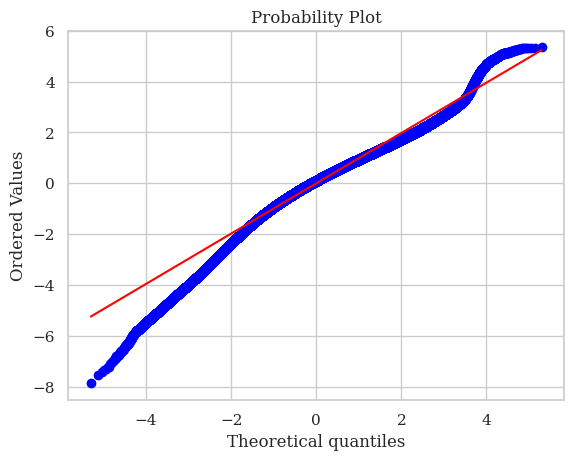

In [16]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib
%matplotlib inline

measurements = np.random.normal(loc = 20, scale = 5, size=100)   
stats.probplot(tl.to_numpy(X_tfr_base).flatten(), dist="norm", plot=plt)
plt.show()


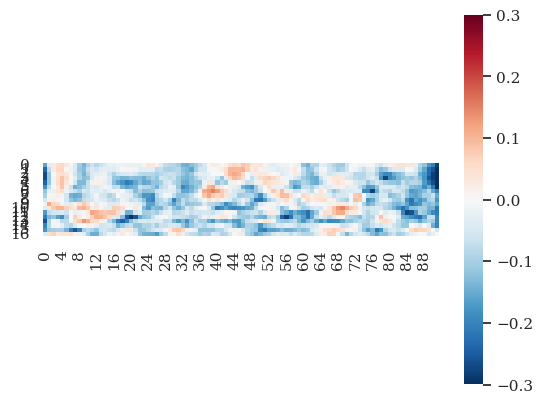

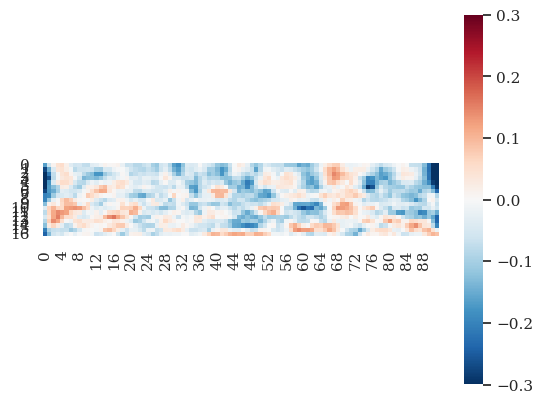

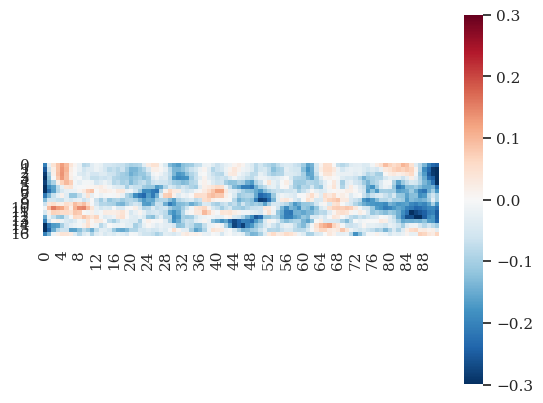

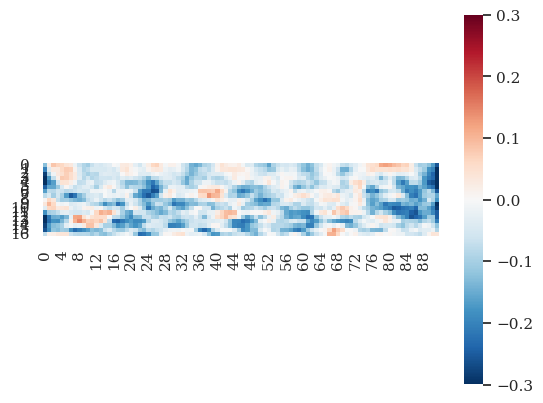

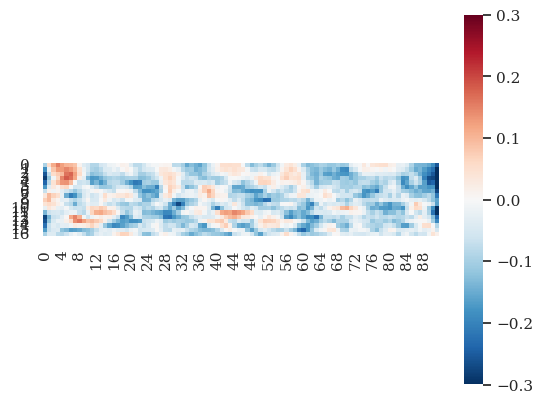

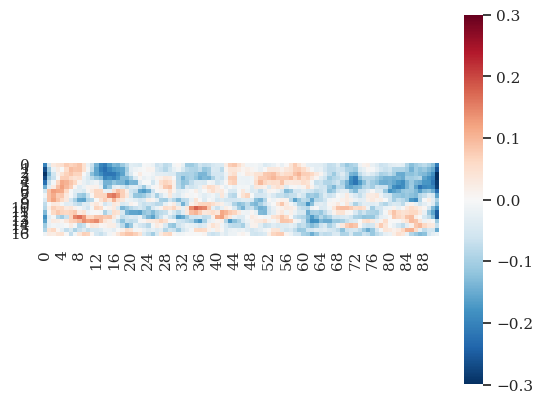

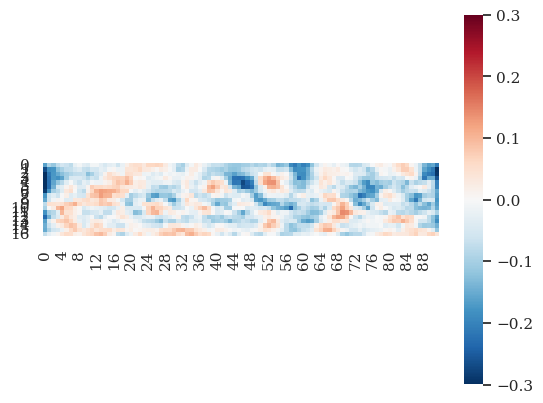

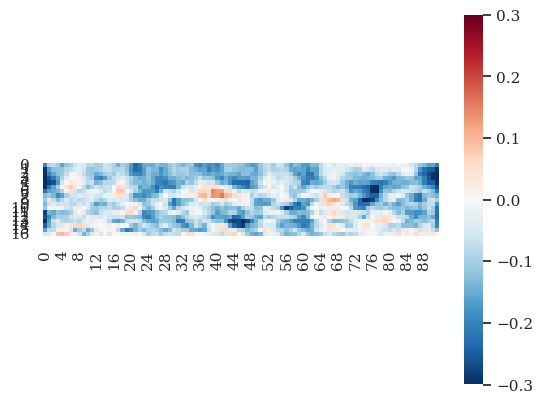

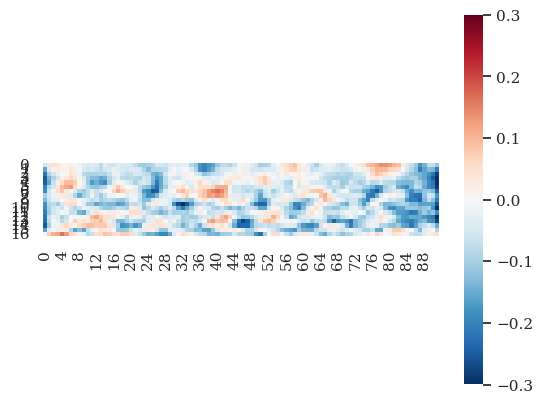

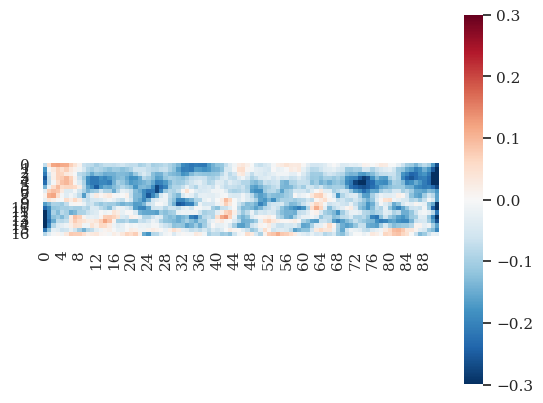

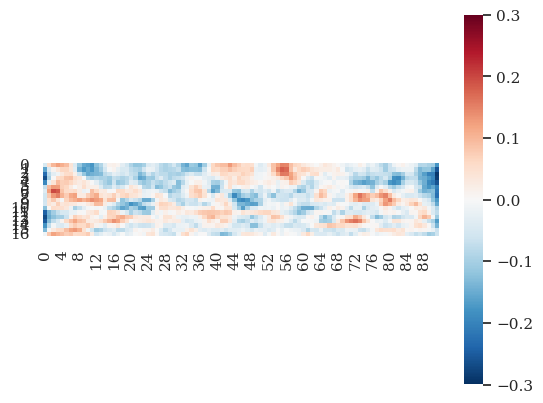

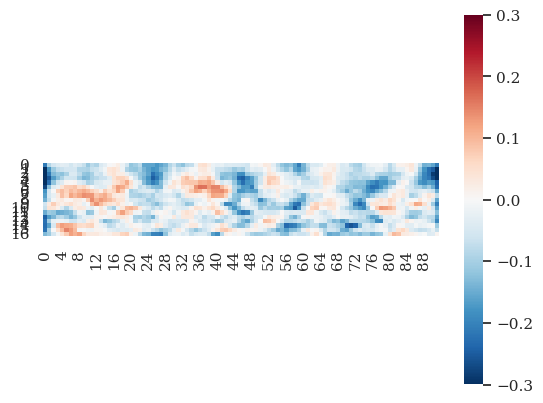

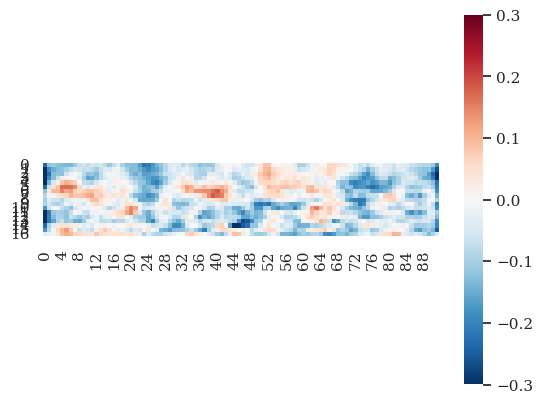

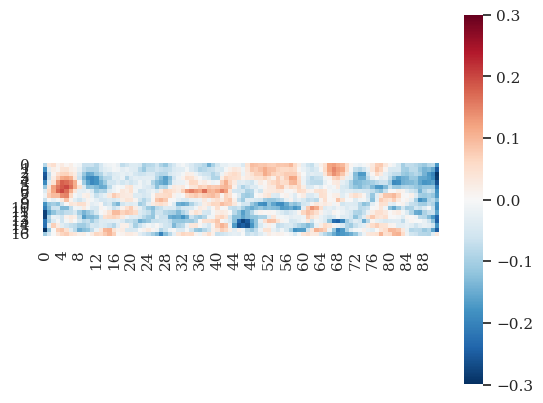

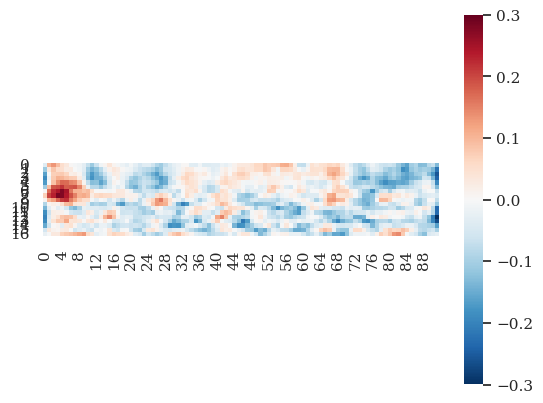

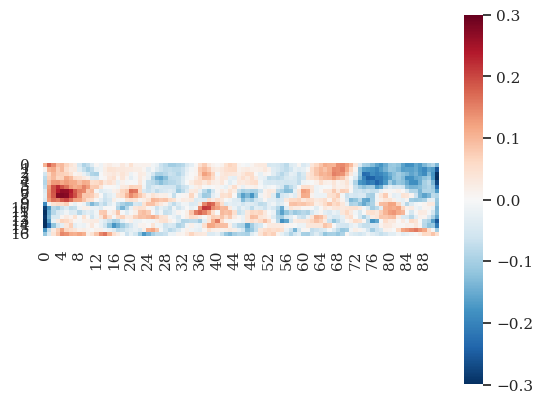

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

x_mean = tl.to_numpy(X_tfr_base[y=='right_hand']).mean(axis=0)
for f in range(x_mean.shape[0]):
    sns.heatmap(x_mean[f], cmap='RdBu_r', center=0, square='True', vmin=-0.3, vmax=0.3)
    plt.show()

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd

x = tl.to_numpy(X_tfr_base.flatten())
hist, bin_edges = np.histogram(x, bins=100000)
bins = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute the mean of each subsequent pair
df = pd.DataFrame({'bins':bins, 'count':hist})
px.histogram(df, x="bins", y="count")

In [19]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=1024,
        tol=1e-6,
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        forward=True,
        theta=0.5,
        refit_shrinkage=True,
)


In [20]:
X_tfr_base = tl.tensor(X_tfr_base)

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from hoda.util import solve_gevdh

plt.style.use('default')
%load_ext line_profiler

hoda.fit_backward(X_tfr_base,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

Backward HODA model rank=(2, 3, 7):   5%|▍         | 49/1024 [00:00<00:18, 53.23it/s]


,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.528540e+00,0.001576,3.428731e+06
1,1,2,2,1.404659e+00,0.003114,3.264102e+06
2,1,3,3,1.425974e+00,0.017976,2.368846e+06
3,2,1,4,6.269762e-01,0.008475,1.872697e+06
4,2,2,5,1.162243e+00,0.010616,2.276771e+06
...,...,...,...,...,...,...
145,49,2,146,3.941792e-07,0.020556,2.347939e+06
146,49,3,147,1.345402e-06,0.046513,1.016639e+06
147,50,1,148,2.447686e-07,0.010141,7.571258e+05
148,50,2,149,2.877256e-07,0.020556,2.347938e+06


In [22]:
import plotly.express as px

px.imshow(tl.to_numpy(hoda.scatter_w_[0]))

In [23]:
import plotly.express as px

px.imshow(tl.to_numpy(hoda.scatter_w_[1]))

In [24]:
import plotly.express as px

px.imshow(tl.to_numpy(hoda.scatter_w_[2]))

In [25]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.528540e+00,0.001576,3.428731e+06
1,1,2,2,1.404659e+00,0.003114,3.264102e+06
2,1,3,3,1.425974e+00,0.017976,2.368846e+06
3,2,1,3,6.269762e-01,0.008475,1.872697e+06
4,2,2,4,1.162243e+00,0.010616,2.276771e+06
...,...,...,...,...,...,...
145,49,2,98,3.941792e-07,0.020556,2.347939e+06
146,49,3,99,1.345402e-06,0.046513,1.016639e+06
147,50,1,99,2.447686e-07,0.010141,7.571258e+05
148,50,2,100,2.877256e-07,0.020556,2.347938e+06


In [26]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr', log_y=False)
    fig.show()

In [27]:
px.line(df, x='iteration', y='update', log_y=True, color='mode')


In [28]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [29]:
px.line(df, x='flip', y='objective', log_y=False, color='mode')

In [30]:
hoda.fit_forward(X_tfr_base,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :   3%|▎         | 34/1023 [00:00<00:12, 82.12it/s]


,iteration,mode,flip,update,lambda_
0,1,1,1,1.712506e+00,0.0
1,1,2,2,1.081406e+00,0.0
2,1,3,3,2.815382e+00,0.0
3,2,1,4,2.801944e-01,0.0
4,2,2,5,7.025011e-01,0.0
...,...,...,...,...,...
100,34,2,101,1.209049e-06,0.0
101,34,3,102,1.136426e-06,0.0
102,35,1,103,2.207443e-07,0.0
103,35,2,104,7.781287e-07,0.0


In [31]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update,lambda_
0,1,1,1,1.712506e+00,0.0
1,1,2,2,1.081406e+00,0.0
2,1,3,3,2.815382e+00,0.0
3,2,1,3,2.801944e-01,0.0
4,2,2,4,7.025011e-01,0.0
...,...,...,...,...,...
100,34,2,68,1.209049e-06,0.0
101,34,3,69,1.136426e-06,0.0
102,35,1,69,2.207443e-07,0.0
103,35,2,70,7.781287e-07,0.0


In [32]:
if hoda.extra_train_info:
    x.line(df, x='flip', y='mse', log_y=True)

In [33]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

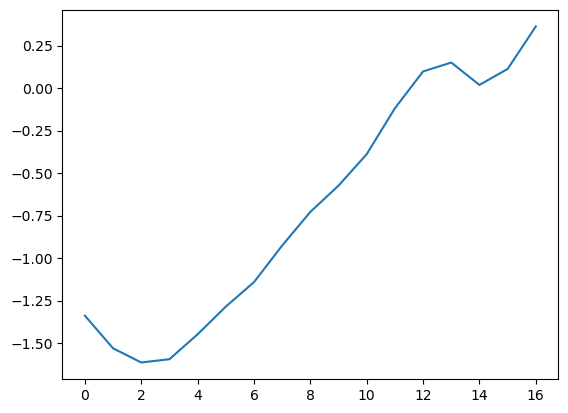

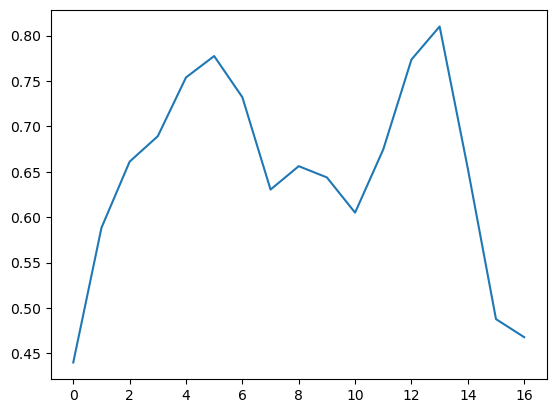

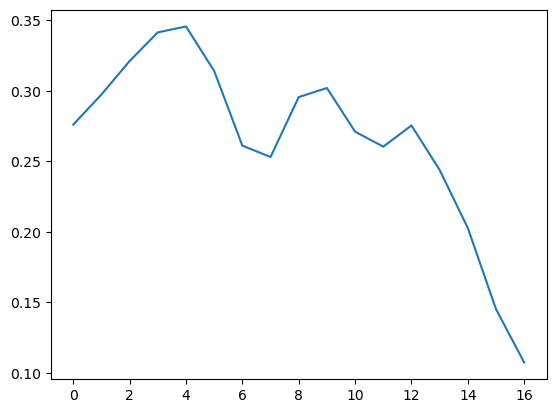

In [34]:
for i in range(hoda.aps_[1].shape[1]):
    plt.plot(tl.to_numpy(hoda.aps_[1][:,i]))
    plt.show()

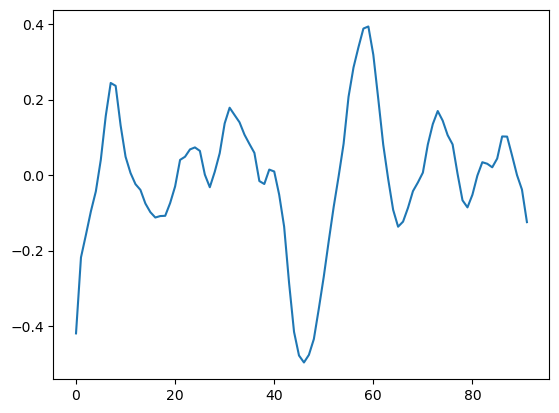

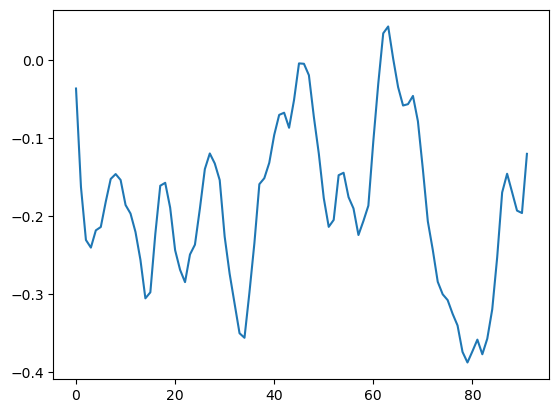

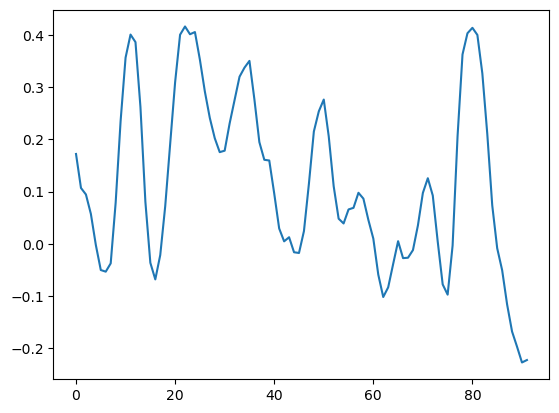

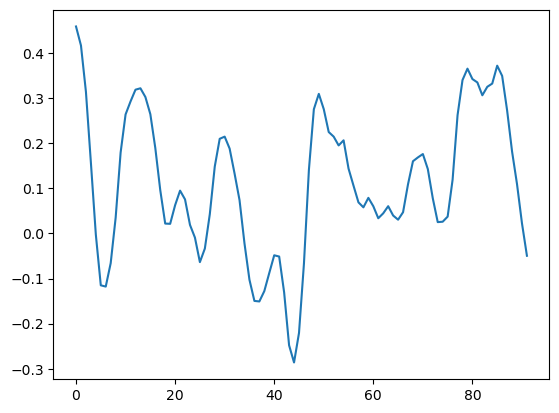

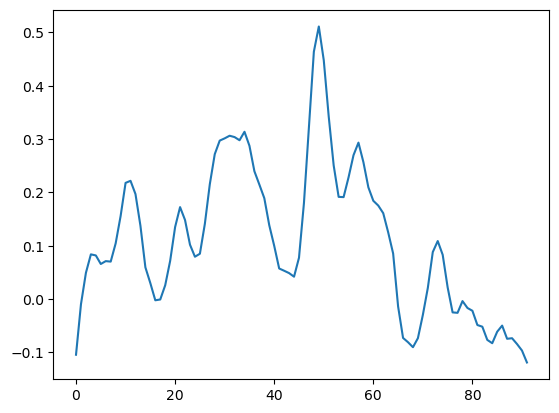

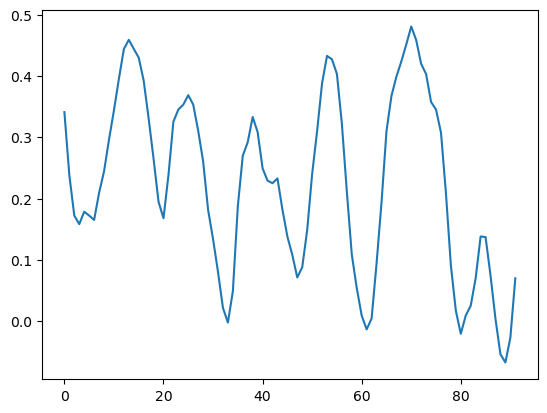

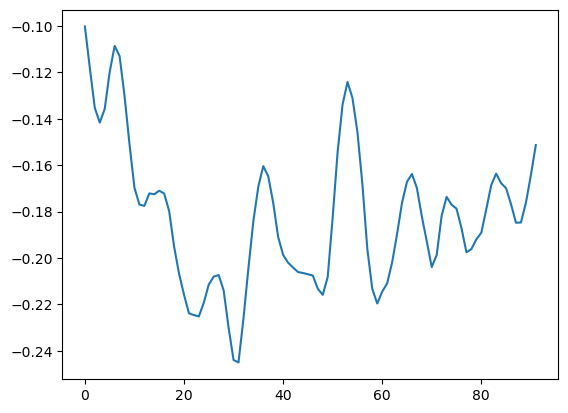

In [35]:
for i in range(hoda.aps_[2].shape[1]):
    plt.plot(tl.to_numpy(hoda.aps_[2][:,i]))
    plt.show()

In [36]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np

Xt = hoda.transform(X_tfr_base)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFdr(alpha=.05)
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'p_value': select.pvalues_,
    'significant': select.get_support()
})
df

,feature,F,p_value,significant
0,0,0.510104,6.007604e-01,False
1,1,1.372266,2.545308e-01,False
2,2,0.217081,8.049439e-01,False
3,3,0.753632,4.712138e-01,False
4,4,1.271281,2.814206e-01,False
5,5,0.006821,9.932022e-01,False
6,6,1.284864,2.776442e-01,False
7,7,2.551293,7.904459e-02,False
8,8,0.788706,4.550241e-01,False
9,9,0.848107,4.288694e-01,False


In [37]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [38]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
x_viz = PCA(whiten=True, n_components=2).fit_transform(xt, y)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_layout(width=1000, height=800)

### 